
# Experimento: Dimensiones

### Tiempo de entrenamiento de SoM (somJ) vs MiniSom en función del nº de dimensiones con 5-fold CV

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from somJ.som import SoM
import somJ.config as config
import os
import time
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import umap
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


In [ ]:


# --- Parámetros ---
n_samples   = 40000
dimensions  = [10, 50, 100, 500, 1000]
n_splits    = 5
out_dir     = 'g_time_comp'
os.makedirs(out_dir, exist_ok=True)

# --- Preparar 5-fold ---
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# --- Diccionarios para acumular tiempos ---
times_som  = {d: [] for d in dimensions}
times_pca  = {d: [] for d in dimensions}
times_lda  = {d: [] for d in dimensions}
times_tsne = {d: [] for d in dimensions}
times_umap = {d: [] for d in dimensions}

for d in dimensions:
    print(f"\n=== Dimensión objetivo: {d} ===")
    rand = np.random.RandomState(0)
    train_data = rand.randint(0, 255, (n_samples, d))
    label_data = rand.randint(0, 10, (n_samples, 1))
    scaler     = MinMaxScaler()
    X_scaled   = scaler.fit_transform(train_data)

    for fold_idx, (train_idx, _) in enumerate(kf.split(X_scaled), start=1):
        X_train = X_scaled[train_idx]
        y_train = label_data[train_idx]
        print(f" Fold {fold_idx}/{n_splits}", end='… ')
        
        # SoM (somJ)
        som = SoM(
            method=config.INIT_METHOD,
            data=X_train,
            total_nodes=config.TOTAL_NODES
        )
        t0 = time.time()
        som.train(
            train_data=X_train,
            learn_rate=config.LEARNING_RATE,
            epochs=1,
            sigma=config.SIGMA,
            decay_rate=config.DECAY_RATE,
            prog_bar=False
        )
        times_som[d].append(time.time() - t0)
        # ---- PCA ----
        t0 = time.time()
        pca = PCA(n_components=2, random_state=42)
        _ = pca.fit_transform(X_train)
        times_pca[d].append(time.time() - t0)
        
        # ---- LDA ----
        t0 = time.time()
        lda = LinearDiscriminantAnalysis(n_components=2)
        _ = lda.fit_transform(X_train, y_train)
        times_lda[d].append(time.time() - t0)
        
        # ---- t-SNE ----
        t0 = time.time()
        tsne = TSNE(n_components=2, init='random', random_state=42, verbose=0)
        _ = tsne.fit_transform(X_train)
        times_tsne[d].append(time.time() - t0)
        
        # ---- UMAP ----
        t0 = time.time()
        umap_model = umap.UMAP(n_components=2, random_state=42)
        _ = umap_model.fit_transform(X_train)
        times_umap[d].append(time.time() - t0)
        
        print("OK")




In [15]:
# --- Cálculo de medias y desviaciones ---
import pandas as pd

results = []
for d in dimensions:
    row = {"dims": d}
    for name, times_dict in [("SOM", times_som),
                                ("PCA", times_pca),
                             ("LDA", times_lda),
                             ("t-SNE", times_tsne),
                             ("UMAP", times_umap)]:
        arr = np.array(times_dict[d], dtype=float)
        row[f"{name}_mean"] = np.nanmean(arr)
        row[f"{name}_std"]  = np.nanstd(arr, ddof=1)
    results.append(row)

df_results = pd.DataFrame(results)
print("\nResumen de tiempos (media ± std) por técnica y dimensión:")
print(df_results.to_string(index=False))


Resumen de tiempos (media ± std) por técnica y dimensión:
 dims  SOM_mean  SOM_std  PCA_mean  PCA_std  LDA_mean  LDA_std  t-SNE_mean  t-SNE_std  UMAP_mean  UMAP_std
    5  5.788635 0.131415  0.002003 0.000194  0.014602 0.000626   54.430685   2.859082  10.748333  0.639133
   10  6.057959 0.083766  0.002584 0.000221  0.033453 0.012035   65.174484   1.816974  10.159779  0.170823
   50  8.417256 0.192005  0.007551 0.000720  0.131481 0.010167   84.850344  12.018919  12.659534  0.433564
  100 11.352373 0.600256  0.017072 0.000831  0.248758 0.054890   83.667659   5.391742  12.800751  0.278792
  500 35.529000 2.128826  0.115740 0.013111  1.207194 0.113880   78.188585   4.661288  16.703481  0.528260
 1000 79.570795 4.354481  0.406374 0.082862  3.431502 0.427378   83.481019   4.146828  18.923631  0.171207


In [16]:
df_results

,dims,SOM_mean,SOM_std,PCA_mean,PCA_std,LDA_mean,LDA_std,t-SNE_mean,t-SNE_std,UMAP_mean,UMAP_std
0,5,5.788635,0.131415,0.002003,0.000194,0.014602,0.000626,54.430685,2.859082,10.748333,0.639133
1,10,6.057959,0.083766,0.002584,0.000221,0.033453,0.012035,65.174484,1.816974,10.159779,0.170823
2,50,8.417256,0.192005,0.007551,0.000720,0.131481,0.010167,84.850344,12.018919,12.659534,0.433564
3,100,11.352373,0.600256,0.017072,0.000831,0.248758,0.054890,83.667659,5.391742,12.800751,0.278792
4,500,35.529000,2.128826,0.115740,0.013111,1.207194,0.113880,78.188585,4.661288,16.703481,0.528260
5,1000,79.570795,4.354481,0.406374,0.082862,3.431502,0.427378,83.481019,4.146828,18.923631,0.171207


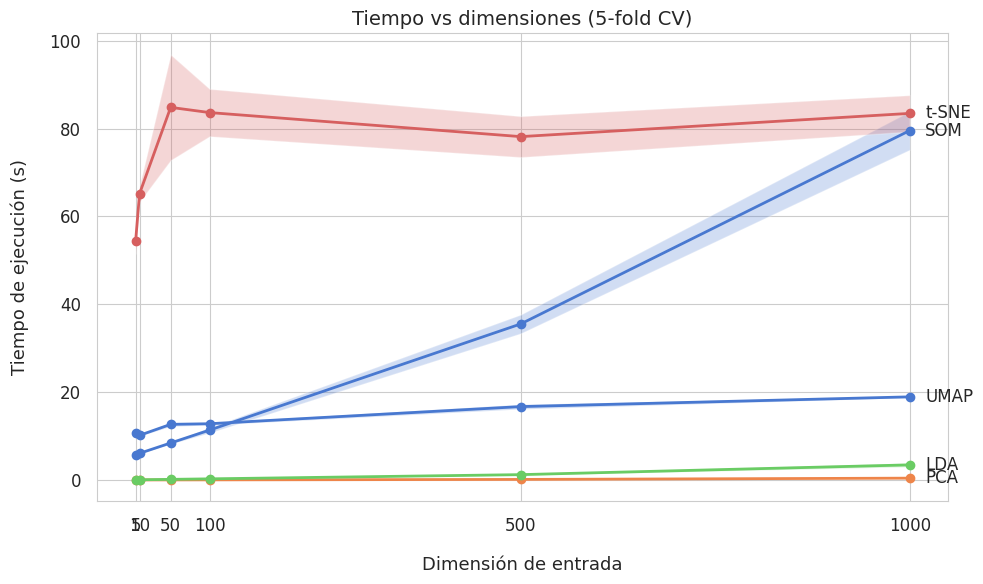

In [19]:

# --- Configuración de estilo ---
sns.set_style('whitegrid')
sns.set_palette('muted', n_colors=4)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

# --- Extraer datos de df_results ---
dims      = df_results['dims'].values
mean_som  = df_results['SOM_mean'].values
std_som   = df_results['SOM_std'].values
mean_pca  = df_results['PCA_mean'].values
std_pca   = df_results['PCA_std'].values
mean_lda  = df_results['LDA_mean'].values
std_lda   = df_results['LDA_std'].values
mean_tsne = df_results['t-SNE_mean'].values
std_tsne  = df_results['t-SNE_std'].values
mean_umap = df_results['UMAP_mean'].values
std_umap  = df_results['UMAP_std'].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

methods = [
    ('SOM',   mean_som,   std_som),
    ('PCA',   mean_pca,   std_pca),
    ('LDA',   mean_lda,   std_lda),
    ('t-SNE', mean_tsne,  std_tsne),
    ('UMAP',  mean_umap,  std_umap),
]

for label, mean_vals, std_vals in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    std_arr  = np.array(std_vals,  dtype=float)
    valid    = ~np.isnan(mean_arr)

    ax.plot(
        dims[valid],
        mean_arr[valid],
        marker='o',
        linewidth=2,
        label=label
    )
    ax.fill_between(
        dims[valid],
        mean_arr[valid] - std_arr[valid],
        mean_arr[valid] + std_arr[valid],
        alpha=0.25
    )

# Etiquetas directas al final de cada curva
for label, mean_vals, _ in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    valid_ix = np.where(~np.isnan(mean_arr))[0]
    if len(valid_ix) > 0:
        last_ix = valid_ix[-1]
        x, y = dims[last_ix], mean_arr[last_ix]
        ax.text(x * 1.02, y, label, va='center')

# Escalas y etiquetas
ax.set_xscale('linear')
ax.set_xticks(dims)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Dimensión de entrada')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title('Tiempo vs dimensiones (5-fold CV)')

plt.tight_layout()
plt.savefig("g_time_comp/tiempo_vs_dimensiones_5fold.png",dpi=300)
plt.show()